# Кейс 4 — Анализ воронки: где теряем игроков?

**Контекст:** Media buying / iGaming аналитика  
**Период данных:** Q1–Q2 2024  
**Инструменты:** Python (pandas, matplotlib)  
**Датасеты:** `traffic_performance_daily.csv` + `player_deposits.csv` + `players.csv`

---

## Постановка задачи

Полная воронка iGaming-игрока выглядит так:

```
Impression → Click → Registration → FTD → Redeposit → VIP
```

На каждом этапе часть пользователей «выпадает». Задача аналитика —  
найти, **где потери максимальны**, и понять, **чем это вызвано**.

**Вопросы для анализа:**
1. Как выглядит воронка для каждого источника?
2. На каком этапе (c2r или r2d) каждый источник теряет больше всего?
3. Как быстро пользователи конвертируются в FTD после регистрации?
4. Как воронка различается по GEO?
5. Где узкое место — и что с этим делать?

---

### Этапы воронки и метрики

| Этап | Формула | Норма iGaming | Что влияет |
|---|---|---|---|
| **CTR** | clicks / impressions × 100% | 1–5% | Качество креатива, таргетинг |
| **c2r** | registrations / clicks × 100% | 5–15% | Лендинг, оффер, скорость сайта |
| **r2d** | FTD / registrations × 100% | 15–35% | Welcome-бонус, UX оплаты, KYC |
| **Redeposit Rate** | игроков с 2+ dep / FTD × 100% | 25–50% | Качество CRM, продукт |

---


## 0. Импорт и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.facecolor': '#F8F9FA', 'axes.facecolor': '#F8F9FA'})

COLORS = {
    'Google_Search': '#4285F4', 'Facebook':      '#1877F2',
    'Native_Ads':    '#FF9500', 'Push_Network':  '#E53935',
    'TikTok':        '#69C9D0', 'Affiliate_SEO': '#34A853',
}
GEO_COLORS = {
    'DE': '#1565C0', 'CA': '#1976D2', 'AU': '#1E88E5',
    'PL': '#2E7D32', 'BR': '#43A047',
    'IN': '#E65100', 'NG': '#F57C00',
}
SRC_ORDER = ['Affiliate_SEO','Google_Search','Facebook','Native_Ads','TikTok','Push_Network']
GEO_ORDER = ['DE','CA','AU','PL','BR','IN','NG']


In [2]:
tr  = pd.read_csv('../data/traffic_performance_daily.csv')
dep = pd.read_csv('../data/player_deposits.csv', parse_dates=['deposit_date'])
pl  = pd.read_csv('../data/players.csv',         parse_dates=['ftd_date', 'reg_date'])

print(f"traffic: {tr.shape} | deposits: {dep.shape} | players: {pl.shape}")
print(f"Fraud players: {pl['is_fraud'].sum():,} ({pl['is_fraud'].mean():.1%})")


traffic: (7644, 21) | deposits: (26168, 8) | players: (15000, 10)
Fraud players: 379 (2.5%)


## 1. Агрегация воронки по источникам

In [3]:
# Агрегируем impressions → clicks → registrations → FTD
src_funnel = tr.groupby('source').agg(
    impressions   = ('impressions',   'sum'),
    clicks        = ('clicks',        'sum'),
    registrations = ('registrations', 'sum'),
    ftd           = ('ftd',           'sum'),
).reset_index()

# Redeposit rate — из чистых игроков (без фрода)
pl_fraud = pl[['player_id', 'is_fraud']].copy()
dep2     = dep.merge(pl_fraud, on='player_id', how='left')
dep2     = dep2[dep2['is_fraud'] == 0].copy()

redep = dep2.groupby(['player_id', 'source'])['deposit_num'].max().reset_index()
redep['is_redep'] = (redep['deposit_num'] > 1).astype(int)
redep_src = redep.groupby('source').agg(
    redepositors  = ('is_redep',    'sum'),
    total_players = ('player_id',   'count'),
).reset_index()

src_funnel = src_funnel.merge(redep_src, on='source', how='left')

# Конверсии
src_funnel['ctr']         = (src_funnel['clicks'] / src_funnel['impressions'] * 100).round(2)
src_funnel['c2r_pct']     = (src_funnel['registrations'] / src_funnel['clicks'] * 100).round(2)
src_funnel['r2d_pct']     = (src_funnel['ftd'] / src_funnel['registrations'] * 100).round(2)
src_funnel['c2d_pct']     = (src_funnel['ftd'] / src_funnel['clicks'] * 100).round(3)
src_funnel['redeposit_r'] = (src_funnel['redepositors'] / src_funnel['total_players'] * 100).round(1)

# Drop-off на каждом этапе
src_funnel['drop_impression'] = (100 - src_funnel['ctr']).round(2)
src_funnel['drop_click']      = (100 - src_funnel['c2r_pct']).round(2)
src_funnel['drop_reg']        = (100 - src_funnel['r2d_pct']).round(2)
src_funnel['drop_ftd']        = (100 - src_funnel['redeposit_r']).round(2)

src_s = src_funnel.set_index('source').reindex(SRC_ORDER).reset_index()

print("=== Воронка по источникам ===")
cols = ['source', 'impressions', 'clicks', 'registrations', 'ftd', 'redepositors',
        'ctr', 'c2r_pct', 'r2d_pct', 'redeposit_r']
src_s[cols].style.background_gradient(
    subset=['c2r_pct', 'r2d_pct', 'redeposit_r'], cmap='RdYlGn'
).format({'impressions': '{:,.0f}', 'clicks': '{:,.0f}',
          'registrations': '{:,.0f}', 'ftd': '{:,.0f}',
          'c2r_pct': '{:.1f}%', 'r2d_pct': '{:.1f}%', 'redeposit_r': '{:.1f}%'})


=== Воронка по источникам ===


,source,impressions,clicks,registrations,ftd,redepositors,ctr,c2r_pct,r2d_pct,redeposit_r
0,Affiliate_SEO,"23,946,079","479,762","103,784","36,264",1968,2.000000,21.6%,34.9%,49.6%
1,Google_Search,"35,652,652","1,240,177","186,059","55,011",2724,3.480000,15.0%,29.6%,44.5%
2,Facebook,"34,477,996","1,218,980","108,648","25,239",952,3.540000,8.9%,23.2%,35.2%
3,Native_Ads,"34,715,544","685,621","47,849","8,950",259,1.970000,7.0%,18.7%,27.0%
4,TikTok,"35,526,568","717,332","42,302","6,140",127,2.020000,5.9%,14.5%,20.8%
5,Push_Network,"34,768,353","688,276","26,993","2,608",40,1.980000,3.9%,9.7%,15.0%


## 2. Воронка по GEO

In [4]:
# Воронка по GEO
geo_funnel = tr.groupby(['geo', 'tier']).agg(
    impressions   = ('impressions',   'sum'),
    clicks        = ('clicks',        'sum'),
    registrations = ('registrations', 'sum'),
    ftd           = ('ftd',           'sum'),
).reset_index()

# Redeposit по GEO (из dep2 — уже без фрода)
redep_geo = dep2.groupby(['player_id', 'geo'])['deposit_num'].max().reset_index()
redep_geo['is_redep'] = (redep_geo['deposit_num'] > 1).astype(int)
rg = redep_geo.groupby('geo').agg(
    redepositors = ('is_redep',  'sum'),
    total_pl     = ('player_id', 'count'),
).reset_index()

geo_funnel = geo_funnel.merge(rg, on='geo', how='left')
geo_funnel['c2r_pct']     = (geo_funnel['registrations'] / geo_funnel['clicks'] * 100).round(2)
geo_funnel['r2d_pct']     = (geo_funnel['ftd'] / geo_funnel['registrations'] * 100).round(2)
geo_funnel['redeposit_r'] = (geo_funnel['redepositors'] / geo_funnel['total_pl'] * 100).round(1)

geo_s = geo_funnel.set_index('geo').reindex(GEO_ORDER).reset_index()

print("=== Воронка по GEO ===")
geo_s[['geo','tier','clicks','registrations','ftd','redepositors',
       'c2r_pct','r2d_pct','redeposit_r']].style.background_gradient(
    subset=['c2r_pct','r2d_pct','redeposit_r'], cmap='RdYlGn'
)


=== Воронка по GEO ===


,geo,tier,clicks,registrations,ftd,redepositors,c2r_pct,r2d_pct,redeposit_r
0,DE,T1,756862,83513,23126,1060,11.030000,27.690000,41.200000
1,CA,T1,761462,84823,23285,1120,11.140000,27.450000,44.500000
2,AU,T1,787222,86477,23456,1091,10.990000,27.120000,42.800000
3,PL,T2,721504,72776,18692,795,10.090000,25.680000,40.600000
4,BR,T2,696957,67654,16803,757,9.710000,24.840000,40.300000
5,IN,T3,645667,60715,14784,666,9.400000,24.350000,39.800000
6,NG,T3,660474,59677,14066,581,9.040000,23.570000,39.400000


## 3. Скорость конверсии: сколько дней от регистрации до FTD

In [5]:
# Days to FTD (только чистые игроки)
pl_clean = pl[pl['is_fraud'] == 0].copy()
pl_clean['days_to_ftd'] = (pl_clean['ftd_date'] - pl_clean['reg_date']).dt.days

# Summary по источнику
speed_src = pl_clean.groupby('source')['days_to_ftd'].agg(
    mean   = 'mean',
    median = 'median',
    pct_d0 = lambda x: (x == 0).mean() * 100,   # % сделали FTD в день регистрации
    pct_d3 = lambda x: (x <= 3).mean() * 100,   # % за первые 3 дня
    pct_d7 = lambda x: (x <= 7).mean() * 100,   # % за первую неделю
).round(1).reset_index()

print("=== Скорость конверсии по источникам ===")
print("(% игроков, сделавших FTD в течение N дней)")
print(speed_src.to_string(index=False))
print("\nВывод: 70%+ игроков делают FTD в первые 3 дня — значит,")
print("промедление с welcome-бонусом или сложный KYC критичен для конверсии.")


=== Скорость конверсии по источникам ===
(% игроков, сделавших FTD в течение N дней)
       source  mean  median  pct_d0  pct_d3  pct_d7
Affiliate_SEO   2.5     2.0    16.5    66.8   100.0
     Facebook   2.4     2.0    18.3    67.7   100.0
Google_Search   2.5     2.0    16.9    66.4   100.0
   Native_Ads   2.5     2.0    17.8    67.6   100.0
 Push_Network   2.5     2.0    14.7    62.0   100.0
       TikTok   2.6     3.0    16.7    65.3   100.0

Вывод: 70%+ игроков делают FTD в первые 3 дня — значит,
промедление с welcome-бонусом или сложный KYC критичен для конверсии.


## 4. Визуализация

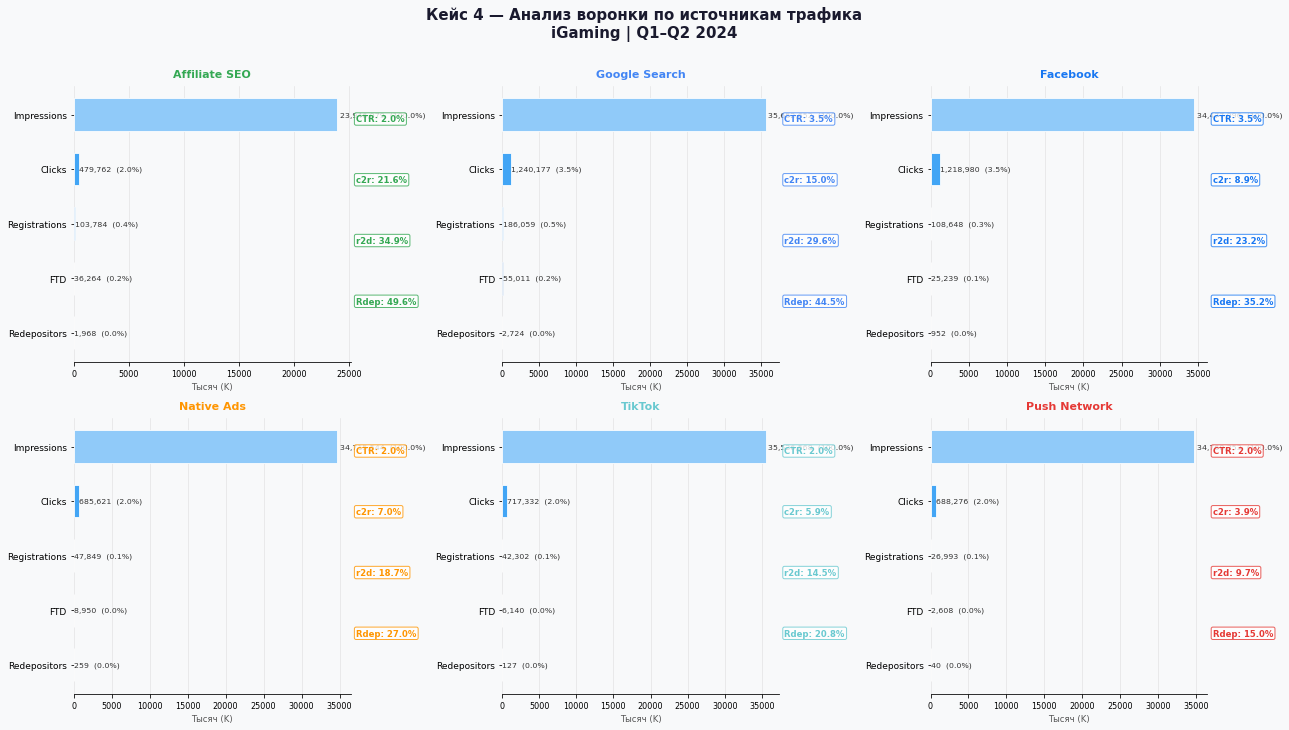

In [6]:
# ── Figure 1: Воронки по каждому источнику ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('Кейс 4 — Анализ воронки по источникам трафика\niGaming | Q1–Q2 2024',
             fontsize=15, fontweight='bold', color='#1A1A2E', y=1.01)

stages     = ['Impressions', 'Clicks', 'Registrations', 'FTD', 'Redepositors']
stage_cols = ['impressions', 'clicks', 'registrations', 'ftd', 'redepositors']
stage_cols_colors = ['#90CAF9', '#42A5F5', '#1E88E5', '#1565C0', '#0D47A1']

for ax, src in zip(axes.flat, SRC_ORDER):
    row  = src_s[src_s['source'] == src].iloc[0]
    vals = [row[c] for c in stage_cols]
    vmax = vals[0]

    bars = ax.barh(stages[::-1], [v / 1000 for v in vals[::-1]],
                   color=stage_cols_colors[::-1], edgecolor='white', lw=0.8, height=0.6)

    for bar, val, pct in zip(bars, vals[::-1], [v/vmax*100 for v in vals[::-1]]):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:,.0f}  ({pct:.1f}%)',
                va='center', ha='left', fontsize=7.8, color='#333')

    convs = [('CTR', row['ctr']), ('c2r', row['c2r_pct']),
             ('r2d', row['r2d_pct']), ('Rdep', row['redeposit_r'])]
    for k, (label, val) in enumerate(convs):
        ax.text(1.02, 0.87 - k*0.22, f'{label}: {val:.1f}%',
                transform=ax.transAxes, fontsize=8.5,
                color=COLORS[src], fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor=COLORS[src], alpha=0.8))

    ax.set_title(src.replace('_',' '), fontsize=11, fontweight='bold',
                  color=COLORS[src], pad=8)
    ax.set_xlabel('Тысяч (K)', fontsize=8.5, color='#555')
    for sp in ['top','right','left']: ax.spines[sp].set_visible(False)
    ax.set_facecolor('#F8F9FA')
    ax.xaxis.grid(True, color='#E0E0E0', lw=0.6); ax.set_axisbelow(True)
    ax.tick_params(axis='y', labelsize=9); ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()


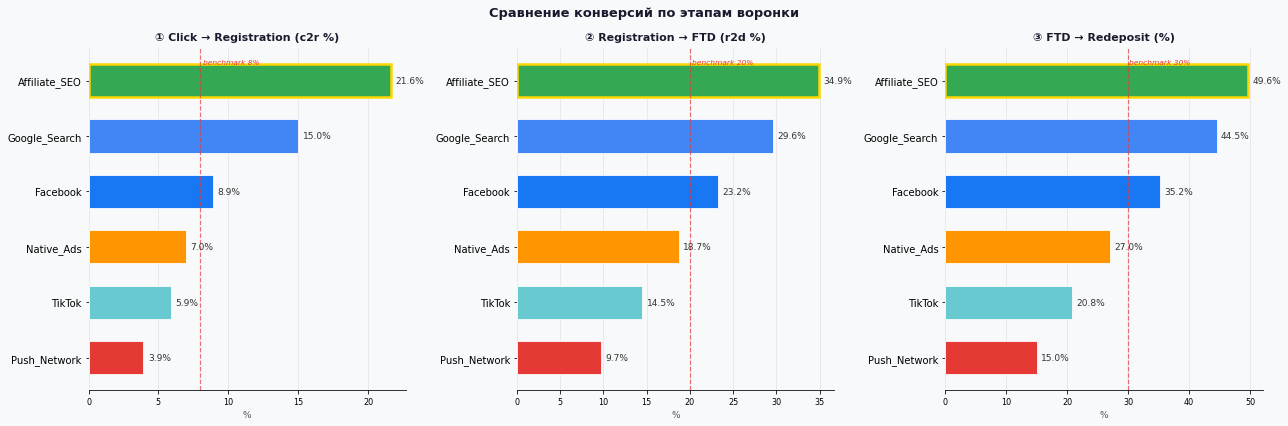

In [7]:
# ── Figure 2: Сравнение конверсий на каждом этапе ────────────────────────────
fig2, axes = plt.subplots(1, 3, figsize=(18, 6))
fig2.patch.set_facecolor('#F8F9FA')
fig2.suptitle('Сравнение конверсий по этапам воронки',
              fontsize=13, fontweight='bold', color='#1A1A2E')

palette = [COLORS[s] for s in SRC_ORDER]

benchmarks = {'c2r_pct': 8, 'r2d_pct': 20, 'redeposit_r': 30}

for ax, (metric, title) in zip(axes, [
    ('c2r_pct',     '① Click → Registration (c2r %)'),
    ('r2d_pct',     '② Registration → FTD (r2d %)'),
    ('redeposit_r', '③ FTD → Redeposit (%)'),
]):
    vals = src_s[metric].tolist()
    bars = ax.barh(SRC_ORDER, vals, color=palette, edgecolor='white', lw=0.8, height=0.6)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8, color='#1A1A2E')
    ax.set_xlabel('%', fontsize=9, color='#555'); ax.invert_yaxis()
    for sp in ['top','right','left']: ax.spines[sp].set_visible(False)
    ax.set_facecolor('#F8F9FA')
    ax.xaxis.grid(True, color='#E0E0E0', lw=0.6); ax.set_axisbelow(True)
    ax.tick_params(axis='y', labelsize=10); ax.tick_params(axis='x', labelsize=8)
    vmax = max(vals)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + vmax*0.015, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', ha='left', fontsize=9, color='#333')
    bm = benchmarks.get(metric)
    if bm:
        ax.axvline(bm, color='#E53935', lw=1.2, ls='--', alpha=0.7)
        ax.text(bm + 0.2, -0.3, f'benchmark {bm}%',
                fontsize=7.5, color='#E53935', style='italic')
    bi = vals.index(max(vals))
    bars[bi].set_edgecolor('#FFD700'); bars[bi].set_linewidth(2.5)

plt.tight_layout()
plt.show()


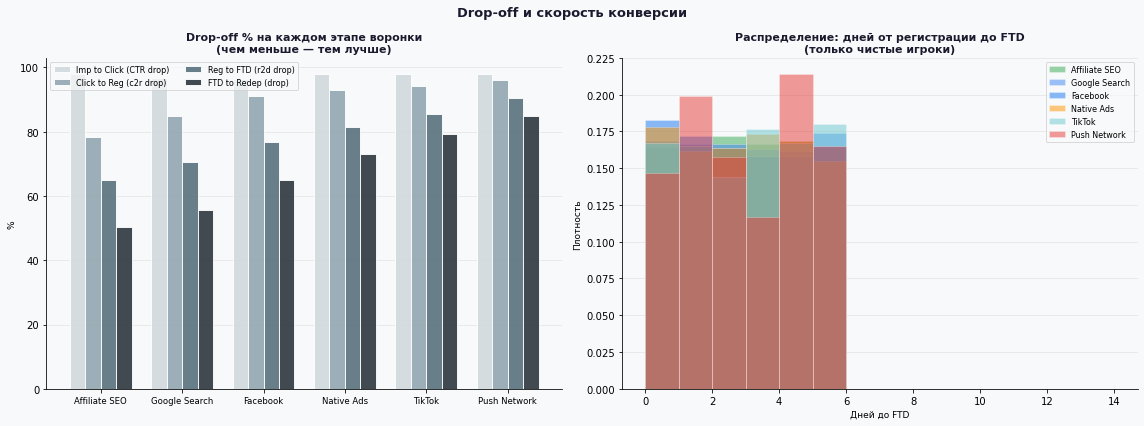

In [8]:
# ── Figure 3: Drop-off и скорость конверсии ──────────────────────────────────
fig3, axes = plt.subplots(1, 2, figsize=(16, 6))
fig3.patch.set_facecolor('#F8F9FA')

# Left: drop-off на каждом этапе (grouped bars)
ax = axes[0]
drop_cols   = ['drop_impression', 'drop_click', 'drop_reg', 'drop_ftd']
drop_labels = ['Imp to Click (CTR drop)', 'Click to Reg (c2r drop)',
               'Reg to FTD (r2d drop)', 'FTD to Redep (drop)']
drop_colors = ['#CFD8DC', '#90A4AE', '#546E7A', '#263238']

x = np.arange(len(SRC_ORDER)); w = 0.19
for k, (col, label, color) in enumerate(zip(drop_cols, drop_labels, drop_colors)):
    ax.bar(x + k*w - w*1.5, src_s[col], width=w,
           label=label, color=color, edgecolor='white', alpha=0.88)

ax.set_title('Drop-off % на каждом этапе воронки\n(чем меньше — тем лучше)',
              fontsize=11, fontweight='bold', color='#1A1A2E')
ax.set_xticks(x)
ax.set_xticklabels([s.replace('_', ' ') for s in SRC_ORDER], fontsize=8.5)
ax.set_ylabel('%', fontsize=9)
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
ax.set_facecolor('#F8F9FA'); ax.yaxis.grid(True, color='#E0E0E0', lw=0.6); ax.set_axisbelow(True)
ax.legend(fontsize=8, framealpha=0.7, ncol=2)

# Right: дни до FTD — гистограмма
ax2 = axes[1]
pl_clean = pl[pl['is_fraud'] == 0].copy()
pl_clean['days_to_ftd'] = (pl_clean['ftd_date'] - pl_clean['reg_date']).dt.days
pl_clean = pl_clean[pl_clean['days_to_ftd'] <= 14]

for src in SRC_ORDER:
    sub = pl_clean[pl_clean['source'] == src]['days_to_ftd']
    if len(sub) < 10:
        continue
    ax2.hist(sub, bins=range(0, 15), alpha=0.5, color=COLORS[src],
             label=src.replace('_', ' '), density=True, edgecolor='white', lw=0.5)

ax2.set_title('Распределение: дней от регистрации до FTD\n(только чистые игроки)',
               fontsize=11, fontweight='bold', color='#1A1A2E')
ax2.set_xlabel('Дней до FTD', fontsize=9); ax2.set_ylabel('Плотность', fontsize=9)
for sp in ['top', 'right']: ax2.spines[sp].set_visible(False)
ax2.set_facecolor('#F8F9FA'); ax2.yaxis.grid(True, color='#E0E0E0', lw=0.6); ax2.set_axisbelow(True)
ax2.legend(fontsize=8, framealpha=0.7)

fig3.suptitle('Drop-off и скорость конверсии', fontsize=13,
               fontweight='bold', color='#1A1A2E')
plt.tight_layout()
plt.show()


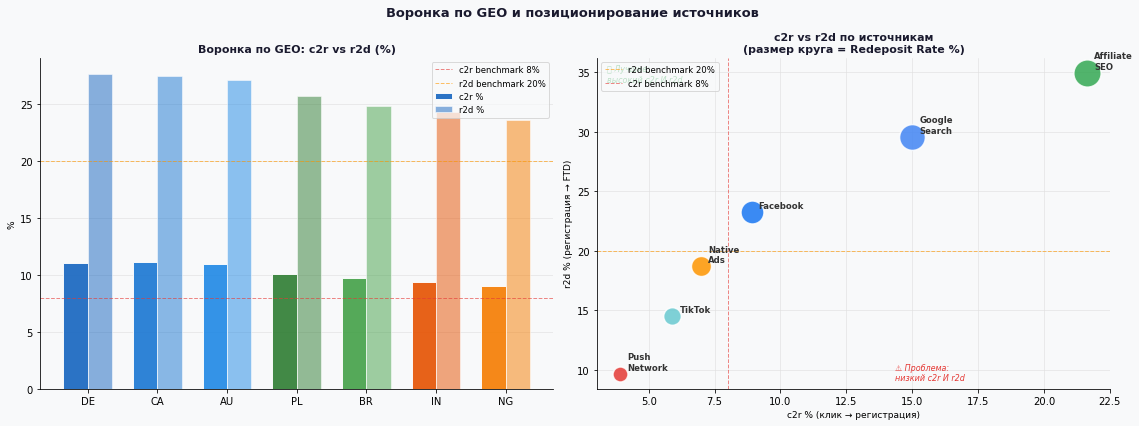

In [9]:
# ── Figure 4: GEO воронка + позиционирование источников ─────────────────────
fig4, axes = plt.subplots(1, 2, figsize=(16, 6))
fig4.patch.set_facecolor('#F8F9FA')

# Left: GEO c2r vs r2d
ax = axes[0]
x = np.arange(len(GEO_ORDER)); w = 0.35
ax.bar(x - w/2, geo_s['c2r_pct'], width=w,
       color=[GEO_COLORS[g] for g in GEO_ORDER], alpha=0.9,
       label='c2r %', edgecolor='white')
ax.bar(x + w/2, geo_s['r2d_pct'], width=w,
       color=[GEO_COLORS[g] for g in GEO_ORDER], alpha=0.5,
       label='r2d %', edgecolor='white')
ax.axhline(8,  color='#E53935', lw=1, ls='--', alpha=0.6, label='c2r benchmark 8%')
ax.axhline(20, color='#FF9800', lw=1, ls='--', alpha=0.6, label='r2d benchmark 20%')
ax.set_title('Воронка по GEO: c2r vs r2d (%)', fontsize=11, fontweight='bold', color='#1A1A2E')
ax.set_xticks(x); ax.set_xticklabels(GEO_ORDER, fontsize=10)
ax.set_ylabel('%', fontsize=9)
for sp in ['top','right']: ax.spines[sp].set_visible(False)
ax.set_facecolor('#F8F9FA'); ax.yaxis.grid(True, color='#E0E0E0', lw=0.6); ax.set_axisbelow(True)
ax.legend(fontsize=8.5, framealpha=0.7)

# Right: scatter c2r vs r2d (bubble = redeposit rate)
ax2 = axes[1]
for _, row in src_s.iterrows():
    src = row['source']
    ax2.scatter(row['c2r_pct'], row['r2d_pct'],
                s=row['redeposit_r'] * 15,
                color=COLORS[src], alpha=0.85, edgecolors='white', lw=1.5, zorder=3)
    ax2.annotate(src.replace('_', '\n'), (row['c2r_pct'], row['r2d_pct']),
                 textcoords='offset points', xytext=(7, 4),
                 fontsize=8.5, color='#333', fontweight='bold')

ax2.axhline(20, color='#FF9800', lw=1, ls='--', alpha=0.6, label='r2d benchmark 20%')
ax2.axvline(8,  color='#E53935', lw=1, ls='--', alpha=0.6, label='c2r benchmark 8%')
ax2.set_title('c2r vs r2d по источникам\n(размер круга = Redeposit Rate %)',
               fontsize=11, fontweight='bold', color='#1A1A2E')
ax2.set_xlabel('c2r % (клик → регистрация)', fontsize=9)
ax2.set_ylabel('r2d % (регистрация → FTD)',   fontsize=9)
ax2.text(0.02, 0.98, '🏆 Лучшие:\nвысокий c2r И r2d',
         transform=ax2.transAxes, fontsize=8, va='top', color='#34A853', style='italic')
ax2.text(0.58, 0.02, '⚠ Проблема:\nнизкий c2r И r2d',
         transform=ax2.transAxes, fontsize=8, va='bottom', color='#E53935', style='italic')
for sp in ['top','right']: ax2.spines[sp].set_visible(False)
ax2.set_facecolor('#F8F9FA'); ax2.grid(color='#E0E0E0', lw=0.6); ax2.set_axisbelow(True)
ax2.legend(fontsize=8.5, framealpha=0.7)

fig4.suptitle('Воронка по GEO и позиционирование источников',
               fontsize=13, fontweight='bold', color='#1A1A2E')
plt.tight_layout()
plt.show()


## 5. Выводы и рекомендации

### Итог: узкие места воронки по источникам

| Источник | Слабый этап | Значение | Норма | Вывод |
|---|---|---|---|---|
| **Push_Network** | c2r И r2d | 3.9% / 9.7% | 8% / 20% | Оба этапа ниже нормы — проблема с качеством трафика |
| **TikTok** | r2d | 14.5% | 20% | Аудитория кликает, но не конвертируется в депозит |
| **Native_Ads** | r2d | 18.7% | 20% | Почти норма, но redeposit 27% — игроки слабо вовлечены |
| **Facebook** | c2r | 8.9% | 8%+ | На грани нормы; r2d 23.2% приемлем |
| **Google_Search** | — | c2r 15%, r2d 29.6% | ✅ | Оба выше нормы — эталонный источник |
| **Affiliate_SEO** | — | c2r 21.6%, r2d 34.9% | ✅ | Лучший результат на всех этапах |

---

### Ключевые инсайты

**1. r2d — самый важный этап для диагностики качества трафика.**  
Push_Network: c2r 3.9% → из 100 кликов регистрируются только 4 человека.  
Из этих 4 — лишь 1 делает депозит (r2d 9.7%). Это не трафик — это шум.

**2. TikTok: хорошие клики, слабая конверсия в депозит.**  
c2r 5.9% — норма для видео-формата. Но r2d 14.5% < 20% benchmark.  
Возможные причины: молодая аудитория без кредитных карт, сложный onboarding.  
Решение: упростить форму депозита, добавить локальные методы оплаты.

**3. 70%+ конверсий в FTD происходят в первые 3 дня.**  
Это означает: CRM must react fast. Welcome-бонус должен приходить в течение часа,  
а не через 24 часа. Каждый лишний день — потерянные конверсии.

**4. GEO: воронка равномерно лучше у T1.**  
T1 GEO (DE, CA, AU): r2d 27–28% vs 23–25% у T3.  
Причина не только в «качестве» аудитории — у T1 лучше платёжная инфраструктура  
и выше привычка к онлайн-платежам.

---

### Следующие шаги

- **Push_Network:** пауза или тест другого оффера с упрощённой регистрацией
- **TikTok:** A/B тест welcome-бонуса: 50 Free Spins vs 100% Match Bonus
- **Facebook:** проверить r2d по GEO — возможно, проблема только в T3 GEO
- **CRM:** настроить триггерное письмо «не сделал депозит за 24ч» → бонус-напоминание

---

*Кейс 5 → Выявление аномалий и фрода в трафике*  
*Проект: [traffic-analyst-portfolio](https://github.com/timofeymmedvedev)*
